
# An?lise do Sport 2026 por competi??o e geral

Este notebook usa os arquivos:

- `data/processed/2026/sport/sport_2026_results.csv`
- `data/processed/2026/sport/sport_2026_team_match_stats.csv`

A an?lise cobre:

- Aproveitamento
- xG pr? e xG contra
- Posse de bola
- Gols marcados
- Gols sofridos
- Gols marcados x xG a favor
- Gols sofridos x xG contra

> Observa??o: `match_id` n?o ? ?nico neste dataset, ent?o a consolida??o ? feita por `source_url`.


In [ ]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

RESULTS_PATH = Path('../data/processed/2026/sport/sport_2026_results.csv')
STATS_PATH = Path('../data/processed/2026/sport/sport_2026_team_match_stats.csv')
TEAM_NAME = 'Sport'


In [ ]:

results = pd.read_csv(RESULTS_PATH)
stats = pd.read_csv(STATS_PATH)

team_stats = stats.loc[stats['team_name'].eq(TEAM_NAME)].copy()
opp_stats = stats.loc[~stats['team_name'].eq(TEAM_NAME)].copy()

matches = (
    results
    .merge(
        team_stats[[
            'source_url',
            'team_name',
            'is_home',
            'possession',
            'expected_goals',
            'data_status',
        ]].rename(
            columns={
                'team_name': 'team_name_stats',
                'expected_goals': 'xg_for',
                'data_status': 'team_data_status',
            }
        ),
        on='source_url',
        how='left',
    )
    .merge(
        opp_stats[[
            'source_url',
            'team_name',
            'expected_goals',
            'data_status',
        ]].rename(
            columns={
                'team_name': 'opponent_from_stats',
                'expected_goals': 'xg_against',
                'data_status': 'opponent_data_status',
            }
        ),
        on='source_url',
        how='left',
    )
)

matches['match_date_utc'] = pd.to_datetime(matches['match_date_utc'], utc=True)
matches['is_home'] = matches['home_team'].eq(TEAM_NAME)
matches['opponent'] = np.where(matches['is_home'], matches['away_team'], matches['home_team'])
matches['goals_for'] = np.where(matches['is_home'], matches['home_score'], matches['away_score'])
matches['goals_against'] = np.where(matches['is_home'], matches['away_score'], matches['home_score'])
matches['points'] = matches['sport_outcome'].map({'win': 3, 'draw': 1, 'loss': 0})
matches['possible_points'] = 3
matches['aproveitamento_jogo'] = matches['points'] / matches['possible_points']
matches['goals_minus_xg_for'] = matches['goals_for'] - matches['xg_for']
matches['goals_against_minus_xg_against'] = matches['goals_against'] - matches['xg_against']

analysis_cols = [
    'match_date_utc',
    'competition_name',
    'competition_round',
    'opponent',
    'sport_outcome',
    'points',
    'goals_for',
    'goals_against',
    'xg_for',
    'xg_against',
    'possession',
    'goals_minus_xg_for',
    'goals_against_minus_xg_against',
    'team_data_status',
]

matches = matches.sort_values(['match_date_utc', 'competition_name', 'opponent']).reset_index(drop=True)
matches[analysis_cols].head()


,match_date_utc,competition_name,competition_round,opponent,sport_outcome,points,goals_for,goals_against,xg_for,xg_against,possession,goals_minus_xg_for,goals_against_minus_xg_against,team_data_status
0,2026-01-10 20:00:00+00:00,"Pernambucano, Serie A1",1,AD Jaguar,draw,1,2,2,NaN,0.80,NaN,NaN,1.20,NaN
1,2026-01-10 20:00:00+00:00,"Pernambucano, Serie A1",1,AD Jaguar,draw,1,2,2,NaN,1.74,NaN,NaN,0.26,NaN
2,2026-01-15 00:30:00+00:00,"Pernambucano, Serie A1",2,Sport Recife,win,3,0,2,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-01-15 00:30:00+00:00,"Pernambucano, Serie A1",2,Sport Recife,win,3,0,2,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-01-15 00:30:00+00:00,"Pernambucano, Serie A1",2,Sport Recife,win,3,0,2,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

def summarize_metrics(df: pd.DataFrame) -> pd.DataFrame:
    summary = pd.DataFrame(
        {
            'jogos': [len(df)],
            'pontos': [df['points'].sum()],
            'aproveitamento_pct': [df['points'].sum() / (len(df) * 3) * 100 if len(df) else np.nan],
            'gols_marcados': [df['goals_for'].sum()],
            'gols_sofridos': [df['goals_against'].sum()],
            'saldo_gols': [df['goals_for'].sum() - df['goals_against'].sum()],
            'xg_pro': [df['xg_for'].sum(min_count=1)],
            'xg_contra': [df['xg_against'].sum(min_count=1)],
            'posse_media_pct': [df['possession'].mean()],
            'gols_marcados_menos_xg_pro': [(df['goals_for'] - df['xg_for']).sum(min_count=1)],
            'gols_sofridos_menos_xg_contra': [(df['goals_against'] - df['xg_against']).sum(min_count=1)],
            'jogos_com_posse': [df['possession'].notna().sum()],
            'jogos_com_xg_pro': [df['xg_for'].notna().sum()],
            'jogos_com_xg_contra': [df['xg_against'].notna().sum()],
        }
    )
    return summary.round(2)


def competition_summary(df: pd.DataFrame) -> pd.DataFrame:
    grouped = []
    for competition, group in df.groupby('competition_name', dropna=False):
        row = summarize_metrics(group)
        row.insert(0, 'competicao', competition)
        grouped.append(row)
    return pd.concat(grouped, ignore_index=True).sort_values(['aproveitamento_pct', 'pontos', 'gols_marcados'], ascending=[False, False, False]).reset_index(drop=True)


geral = summarize_metrics(matches)
por_competicao = competition_summary(matches)

print('Base consolidada por jogo')
display(matches[analysis_cols])

print('Resumo geral')
display(geral)

print('Resumo por competi??o')
display(por_competicao)


Base consolidada por jogo


,match_date_utc,competition_name,competition_round,opponent,sport_outcome,points,goals_for,goals_against,xg_for,xg_against,possession,goals_minus_xg_for,goals_against_minus_xg_against,team_data_status
0,2026-01-10 20:00:00+00:00,"Pernambucano, Serie A1",1,AD Jaguar,draw,1,2,2,NaN,0.80,NaN,NaN,1.20,NaN
1,2026-01-10 20:00:00+00:00,"Pernambucano, Serie A1",1,AD Jaguar,draw,1,2,2,NaN,1.74,NaN,NaN,0.26,NaN
2,2026-01-15 00:30:00+00:00,"Pernambucano, Serie A1",2,Sport Recife,win,3,0,2,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-01-15 00:30:00+00:00,"Pernambucano, Serie A1",2,Sport Recife,win,3,0,2,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-01-15 00:30:00+00:00,"Pernambucano, Serie A1",2,Sport Recife,win,3,0,2,NaN,NaN,NaN,NaN,NaN,NaN
5,2026-01-15 00:30:00+00:00,"Pernambucano, Serie A1",2,Sport Recife,win,3,0,2,NaN,NaN,NaN,NaN,NaN,NaN
6,2026-01-15 00:30:00+00:00,"Pernambucano, Serie A1",2,Sport Recife,win,3,0,2,NaN,NaN,NaN,NaN,NaN,NaN
7,2026-01-15 00:30:00+00:00,"Pernambucano, Serie A1",2,Sport Recife,win,3,0,2,NaN,NaN,NaN,NaN,NaN,NaN
8,2026-01-18 21:00:00+00:00,"Pernambucano, Serie A1",3,Náutico,loss,0,0,4,NaN,0.69,NaN,NaN,3.31,NaN
9,2026-01-18 21:00:00+00:00,"Pernambucano, Serie A1",3,Náutico,loss,0,0,4,NaN,3.08,NaN,NaN,0.92,NaN


Resumo geral


,jogos,pontos,aproveitamento_pct,gols_marcados,gols_sofridos,saldo_gols,xg_pro,xg_contra,posse_media_pct,gols_marcados_menos_xg_pro,gols_sofridos_menos_xg_contra,jogos_com_posse,jogos_com_xg_pro,jogos_com_xg_contra
0,54,126,77.78,82,102,-20,NaN,53.76,NaN,NaN,18.24,0,0,36


Resumo por competi??o


,competicao,jogos,pontos,aproveitamento_pct,gols_marcados,gols_sofridos,saldo_gols,xg_pro,xg_contra,posse_media_pct,gols_marcados_menos_xg_pro,gols_sofridos_menos_xg_contra,jogos_com_posse,jogos_com_xg_pro,jogos_com_xg_contra
0,Copa do Nordeste,4,12,100.00,4,4,0,NaN,4.85,NaN,NaN,-0.85,0,0,4
1,"Pernambucano, Serie A1, Playoffs",20,52,86.67,42,30,12,NaN,15.08,NaN,NaN,-3.08,0,0,8
2,"Pernambucano, Serie A1",18,40,74.07,8,46,-38,NaN,19.53,NaN,NaN,14.47,0,0,12
3,Copa Betano do Brasil,6,12,66.67,22,18,4,NaN,6.66,NaN,NaN,11.34,0,0,6
4,Brasileirão Série B,6,10,55.56,6,4,2,NaN,7.64,NaN,NaN,-3.64,0,0,6



## Leitura r?pida das m?tricas

- `aproveitamento_pct`: pontos conquistados sobre o total poss?vel.
- `xg_pro` e `xg_contra`: soma do xG do Sport e dos advers?rios.
- `gols_marcados_menos_xg_pro`: positivo indica que o time marcou acima do xG acumulado.
- `gols_sofridos_menos_xg_contra`: positivo indica que sofreu mais gols do que o xG cedido sugeria.


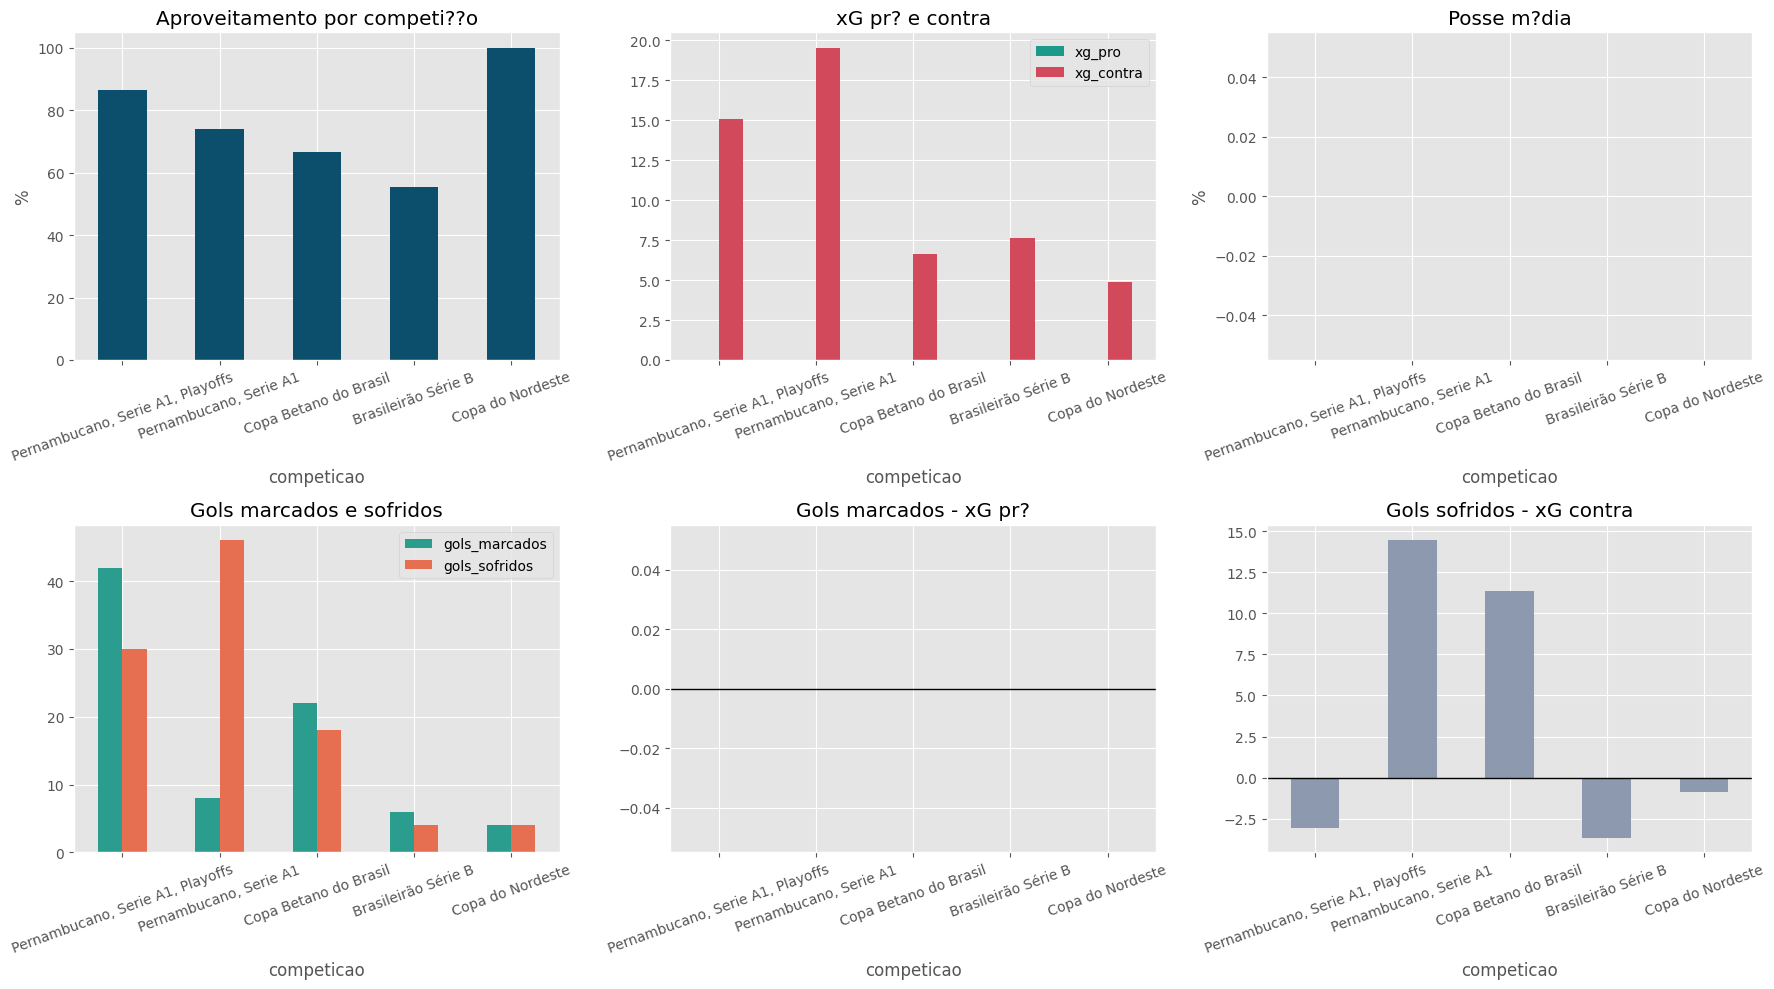

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
summary_plot = por_competicao.sort_values('jogos', ascending=False).copy()

summary_plot.plot.bar(x='competicao', y='aproveitamento_pct', ax=axes[0, 0], legend=False, color='#0B4F6C')
axes[0, 0].set_title('Aproveitamento por competi??o')
axes[0, 0].set_ylabel('%')
axes[0, 0].tick_params(axis='x', rotation=20)

summary_plot.plot.bar(x='competicao', y=['xg_pro', 'xg_contra'], ax=axes[0, 1], color=['#1B998B', '#D1495B'])
axes[0, 1].set_title('xG pr? e contra')
axes[0, 1].tick_params(axis='x', rotation=20)

summary_plot.plot.bar(x='competicao', y='posse_media_pct', ax=axes[0, 2], legend=False, color='#F4A261')
axes[0, 2].set_title('Posse m?dia')
axes[0, 2].set_ylabel('%')
axes[0, 2].tick_params(axis='x', rotation=20)

summary_plot.plot.bar(x='competicao', y=['gols_marcados', 'gols_sofridos'], ax=axes[1, 0], color=['#2A9D8F', '#E76F51'])
axes[1, 0].set_title('Gols marcados e sofridos')
axes[1, 0].tick_params(axis='x', rotation=20)

summary_plot.plot.bar(x='competicao', y='gols_marcados_menos_xg_pro', ax=axes[1, 1], legend=False, color='#264653')
axes[1, 1].axhline(0, color='black', linewidth=1)
axes[1, 1].set_title('Gols marcados - xG pr?')
axes[1, 1].tick_params(axis='x', rotation=20)

summary_plot.plot.bar(x='competicao', y='gols_sofridos_menos_xg_contra', ax=axes[1, 2], legend=False, color='#8D99AE')
axes[1, 2].axhline(0, color='black', linewidth=1)
axes[1, 2].set_title('Gols sofridos - xG contra')
axes[1, 2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


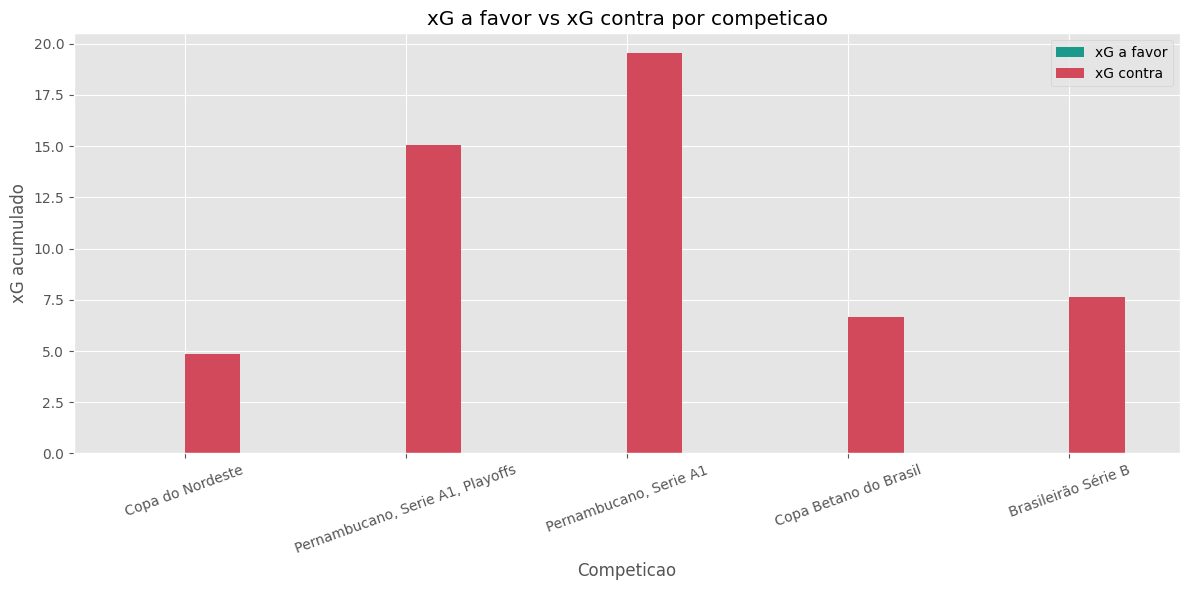

In [ ]:

fig, ax = plt.subplots(figsize=(12, 6))
comparison = por_competicao[['competicao', 'xg_pro', 'xg_contra']].copy()
comparison = comparison.sort_values('xg_pro', ascending=False)

comparison.plot.bar(
    x='competicao',
    y=['xg_pro', 'xg_contra'],
    ax=ax,
    color=['#1B998B', '#D1495B'],
)

ax.set_title('xG a favor vs xG contra por competicao')
ax.set_xlabel('Competicao')
ax.set_ylabel('xG acumulado')
ax.tick_params(axis='x', rotation=20)
ax.legend(['xG a favor', 'xG contra'])

plt.tight_layout()
plt.show()


In [ ]:

detalhe_competicao = (
    matches[
        [
            'match_date_utc',
            'competition_name',
            'competition_round',
            'opponent',
            'sport_outcome',
            'goals_for',
            'goals_against',
            'xg_for',
            'xg_against',
            'possession',
            'goals_minus_xg_for',
            'goals_against_minus_xg_against',
        ]
    ]
    .assign(match_date=lambda df: df['match_date_utc'].dt.strftime('%Y-%m-%d'))
    .drop(columns='match_date_utc')
)

for competition, group in detalhe_competicao.groupby('competition_name', sort=False):
    print(f'Competi??o: {competition}')
    display(group.reset_index(drop=True).round(2))


Competi??o: Pernambucano, Serie A1


,competition_name,competition_round,opponent,sport_outcome,goals_for,goals_against,xg_for,xg_against,possession,goals_minus_xg_for,goals_against_minus_xg_against,match_date
0,"Pernambucano, Serie A1",1,AD Jaguar,draw,2,2,NaN,0.80,NaN,NaN,1.20,2026-01-10
1,"Pernambucano, Serie A1",1,AD Jaguar,draw,2,2,NaN,1.74,NaN,NaN,0.26,2026-01-10
2,"Pernambucano, Serie A1",2,Sport Recife,win,0,2,NaN,NaN,NaN,NaN,NaN,2026-01-15
3,"Pernambucano, Serie A1",2,Sport Recife,win,0,2,NaN,NaN,NaN,NaN,NaN,2026-01-15
4,"Pernambucano, Serie A1",2,Sport Recife,win,0,2,NaN,NaN,NaN,NaN,NaN,2026-01-15
5,"Pernambucano, Serie A1",2,Sport Recife,win,0,2,NaN,NaN,NaN,NaN,NaN,2026-01-15
6,"Pernambucano, Serie A1",2,Sport Recife,win,0,2,NaN,NaN,NaN,NaN,NaN,2026-01-15
7,"Pernambucano, Serie A1",2,Sport Recife,win,0,2,NaN,NaN,NaN,NaN,NaN,2026-01-15
8,"Pernambucano, Serie A1",3,Náutico,loss,0,4,NaN,0.69,NaN,NaN,3.31,2026-01-18
9,"Pernambucano, Serie A1",3,Náutico,loss,0,4,NaN,3.08,NaN,NaN,0.92,2026-01-18


Competi??o: Pernambucano, Serie A1, Playoffs


,competition_name,competition_round,opponent,sport_outcome,goals_for,goals_against,xg_for,xg_against,possession,goals_minus_xg_for,goals_against_minus_xg_against,match_date
0,"Pernambucano, Serie A1, Playoffs",28,Retrô,win,1,0,NaN,NaN,NaN,NaN,NaN,2026-02-12
1,"Pernambucano, Serie A1, Playoffs",28,Retrô,win,1,0,NaN,NaN,NaN,NaN,NaN,2026-02-12
2,"Pernambucano, Serie A1, Playoffs",28,Retrô,win,1,0,NaN,NaN,NaN,NaN,NaN,2026-02-12
3,"Pernambucano, Serie A1, Playoffs",28,Retrô,win,1,0,NaN,NaN,NaN,NaN,NaN,2026-02-12
4,"Pernambucano, Serie A1, Playoffs",28,Retrô,win,1,0,NaN,NaN,NaN,NaN,NaN,2026-02-12
5,"Pernambucano, Serie A1, Playoffs",28,Retrô,win,1,0,NaN,NaN,NaN,NaN,NaN,2026-02-12
6,"Pernambucano, Serie A1, Playoffs",28,Sport Recife,win,2,3,NaN,NaN,NaN,NaN,NaN,2026-02-21
7,"Pernambucano, Serie A1, Playoffs",28,Sport Recife,win,2,3,NaN,NaN,NaN,NaN,NaN,2026-02-21
8,"Pernambucano, Serie A1, Playoffs",28,Sport Recife,win,2,3,NaN,NaN,NaN,NaN,NaN,2026-02-21
9,"Pernambucano, Serie A1, Playoffs",28,Sport Recife,win,2,3,NaN,NaN,NaN,NaN,NaN,2026-02-21


Competi??o: Copa Betano do Brasil


,competition_name,competition_round,opponent,sport_outcome,goals_for,goals_against,xg_for,xg_against,possession,goals_minus_xg_for,goals_against_minus_xg_against,match_date
0,Copa Betano do Brasil,2,Desportiva Ferroviária,win,4,3,NaN,0.84,NaN,NaN,2.16,2026-03-05
1,Copa Betano do Brasil,2,Desportiva Ferroviária,win,4,3,NaN,1.87,NaN,NaN,1.13,2026-03-05
2,Copa Betano do Brasil,3,Sport Recife,win,4,5,NaN,1.07,NaN,NaN,3.93,2026-03-13
3,Copa Betano do Brasil,3,Sport Recife,win,4,5,NaN,1.00,NaN,NaN,4.00,2026-03-13
4,Copa Betano do Brasil,4,Sport Recife,loss,3,1,NaN,0.81,NaN,NaN,0.19,2026-03-18
5,Copa Betano do Brasil,4,Sport Recife,loss,3,1,NaN,1.07,NaN,NaN,-0.07,2026-03-18


Competi??o: Brasileirão Série B


,competition_name,competition_round,opponent,sport_outcome,goals_for,goals_against,xg_for,xg_against,possession,goals_minus_xg_for,goals_against_minus_xg_against,match_date
0,Brasileirão Série B,1,Cuiabá,draw,0,0,NaN,1.32,NaN,NaN,-1.32,2026-03-21
1,Brasileirão Série B,1,Cuiabá,draw,0,0,NaN,0.92,NaN,NaN,-0.92,2026-03-21
2,Brasileirão Série B,2,Sport Recife,draw,1,1,NaN,0.68,NaN,NaN,0.32,2026-04-01
3,Brasileirão Série B,2,Sport Recife,draw,1,1,NaN,1.64,NaN,NaN,-0.64,2026-04-01
4,Brasileirão Série B,3,Londrina,win,2,1,NaN,0.85,NaN,NaN,0.15,2026-04-04
5,Brasileirão Série B,3,Londrina,win,2,1,NaN,2.23,NaN,NaN,-1.23,2026-04-04


Competi??o: Copa do Nordeste


,competition_name,competition_round,opponent,sport_outcome,goals_for,goals_against,xg_for,xg_against,possession,goals_minus_xg_for,goals_against_minus_xg_against,match_date
0,Copa do Nordeste,1,Sport Recife,win,1,2,NaN,0.51,NaN,NaN,1.49,2026-03-25
1,Copa do Nordeste,1,Sport Recife,win,1,2,NaN,1.26,NaN,NaN,0.74,2026-03-25
2,Copa do Nordeste,2,ABC,win,1,0,NaN,2.06,NaN,NaN,-2.06,2026-03-29
3,Copa do Nordeste,2,ABC,win,1,0,NaN,1.02,NaN,NaN,-1.02,2026-03-29


In [ ]:

insights = por_competicao.copy()
insights['aproveitamento_pct'] = insights['aproveitamento_pct'].map(lambda v: f'{v:.2f}%')
insights['posse_media_pct'] = insights['posse_media_pct'].map(lambda v: f'{v:.2f}%' if pd.notna(v) else 'sem dado')
insights['gols_marcados_menos_xg_pro'] = insights['gols_marcados_menos_xg_pro'].map(lambda v: f'{v:+.2f}')
insights['gols_sofridos_menos_xg_contra'] = insights['gols_sofridos_menos_xg_contra'].map(lambda v: f'{v:+.2f}')

print('Leituras objetivas por competi??o')
display(insights[[
    'competicao',
    'aproveitamento_pct',
    'xg_pro',
    'xg_contra',
    'posse_media_pct',
    'gols_marcados',
    'gols_sofridos',
    'gols_marcados_menos_xg_pro',
    'gols_sofridos_menos_xg_contra',
    'jogos_com_posse',
]])


Leituras objetivas por competi??o


,competicao,aproveitamento_pct,xg_pro,xg_contra,posse_media_pct,gols_marcados,gols_sofridos,gols_marcados_menos_xg_pro,gols_sofridos_menos_xg_contra,jogos_com_posse
0,Copa do Nordeste,100.00%,NaN,4.85,sem dado,4,4,+nan,-0.85,0
1,"Pernambucano, Serie A1, Playoffs",86.67%,NaN,15.08,sem dado,42,30,+nan,-3.08,0
2,"Pernambucano, Serie A1",74.07%,NaN,19.53,sem dado,8,46,+nan,+14.47,0
3,Copa Betano do Brasil,66.67%,NaN,6.66,sem dado,22,18,+nan,+11.34,0
4,Brasileirão Série B,55.56%,NaN,7.64,sem dado,6,4,+nan,-3.64,0
